# Lab 11：把故事模型變成聊天助理——SFT、step by step、工具使用

對應講義：[第 11 課](../lessons/11_sft_and_chat.md)

需要 Lab 06 的 `checkpoints/base_model.pt`。

1. base model 不會對話：它從沒見過 chat 的特殊 token
2. SFT 資料：講故事 ＋ 加法（三種回答格式：直接、step by step、計算機）；loss mask（式 11.1）
3. SFT 之後：格式、講故事、三種格式的加法正確率
4. 遮罩的效果：只算助理 token vs 全部 token
5. 存下 `checkpoints/sft_model.pt` 給 Lab 12

CPU 約 18 分鐘（兩次 SFT 各約 8 分鐘）。

In [1]:
import copy
import random
import time

import matplotlib.pyplot as plt
import numpy as np
import torch

from lm_course.utils import notebook_logging, set_seed

%matplotlib inline
plt.rcParams["figure.dpi"] = 80
notebook_logging()
set_seed(0)

In [2]:
from lm_course.artifacts import course_stories, course_tokenizer, load_base_model
from lm_course.chat import SPECIAL_TOKENS

tok = course_tokenizer()
base = load_base_model()
train_stories, _ = course_stories()
print("special tokens:", {t: tok.special_id(t) for t in SPECIAL_TOKENS})

special tokens: {'<|bos|>': 4087, '<|user_start|>': 4088, '<|user_end|>': 4089, '<|assistant_start|>': 4090, '<|assistant_end|>': 4091, '<|python_start|>': 4092, '<|python_end|>': 4093, '<|output_start|>': 4094, '<|output_end|>': 4095}


## 1. base model 不會對話

把一個問題照 chat 格式渲染（`render_for_completion`），交給 base model 接著寫。

In [3]:
from lm_course.chat import ChatEngine, render_for_completion
from lm_course.sampling import next_token_probs

engine = ChatEngine(base, tok)
for question in ["What is 23 + 45?", "Tell me a story about a cat."]:
    reply = engine.reply([{"role": "user", "content": question}], max_tokens=40, temperature=0.0)
    print(f"{question!r} -> {tok.decode(reply.tokens)!r}")

prompt = render_for_completion(tok, [{"role": "user", "content": "What is 23 + 45?"}])
with torch.no_grad():
    probs = next_token_probs(base(torch.tensor([prompt]))[0, -1:])[0]
end = tok.special_id("<|assistant_end|>")
print(f"\nP(<|assistant_end|>) after the prompt: {probs[end].item():.2e}   (uniform would be {1 / tok.vocab_size:.2e})")

'What is 23 + 45?' -> ' 3 year old. He was so excited to explore the world around him. He wanted to go on a adventure, so he decided to go on a journey. \nHe walked around the park,'
'Tell me a story about a cat.' -> ' was very happy and excited. He wanted to show his friends how to play with the other animals. He thought it was fun to play with.\nHe ran to his friends and said, "Let\'s'

P(<|assistant_end|>) after the prompt: 4.08e-09   (uniform would be 2.44e-04)


base model 從沒看過 `<|user_start|>` 這類 token（預訓練資料只有 `<|bos|>`），它只會把前面的文字當成某個故事的開頭繼續寫下去；`<|assistant_end|>` 的機率幾乎為 0——它不知道什麼時候該停。

## 2. SFT 的資料

- 講故事：使用者要一個關於某個主題的故事，回答是一篇含有那個詞的 TinyStories 故事（4,000 段）。
- 加法（講義 §2.4）：2 位數與 3 位數，三種問法各有對應的回答格式。
- 測試題：訓練時沒出現過的數對。

In [4]:
from lm_course.chat import addition_problems, render_conversation, story_conversations

rng = random.Random(0)
two = addition_problems(6000, 2, seed=0)
three = addition_problems(6000, 3, seed=1)
seen = {(p.a, p.b) for p in two + three}
test2 = addition_problems(100, 2, seed=2, exclude=seen)
test3 = addition_problems(100, 3, seed=3, exclude=seen)

conversations = []
conversations += [p.conversation("direct", rng) for p in two[:3000]]
conversations += [p.conversation("steps", rng) for p in two[3000:5000] + three[:2000]]
conversations += [p.conversation("tool", rng) for p in two[5000:5500] + three[2000:3000]]
conversations += story_conversations(train_stories, seed=0)[:4000]
rng.shuffle(conversations)
rendered = [render_conversation(tok, c, max_tokens=256) for c in conversations]
print(f"{len(conversations):,} conversations, mean {np.mean([len(ids) for ids, _ in rendered]):.0f} tokens")

12,169 conversations, mean 90 tokens


看一段渲染後的對話：`[...]` 裡的 token 遮罩為 1（要訓練），其餘為 0（只當上下文）。

In [5]:
def show_mask(ids: list[int], mask: list[int]) -> str:
    out = []
    for token, m in zip(ids, mask):
        text = tok.decode([token])
        out.append(f"[{text}]" if m else text)
    return "".join(out)

for style in ("direct", "steps", "tool"):
    ids, mask = render_conversation(tok, two[0].conversation(style))
    print(f"--- {style}: {sum(mask)} of {len(ids)} tokens trained ---")
    print(show_mask(ids, mask))

--- direct: 15 of 30 tokens trained ---
<|bos|><|user_start|>What is 49 plus 97?<|user_end|><|assistant_start|>[4][9][ ][+][ ][9][7][ ][=][ ][1][4][6][.][<|assistant_end|>]
--- steps: 66 of 87 tokens trained ---
<|bos|><|user_start|>What is 49 plus 97? Think step by step.<|user_end|><|assistant_start|>[9][ ][+][ ][7][ ][=][ ][1][6][,][ write][ ][6][ carry][ ][1][.][ ][4][ ][+][ ][9][ ][+][ ][1][ ][=][ ][1][4][,][ write][ ][4][ carry][ ][1][.][ W][r][ite][ the][ carry][ ][1][.][ So][ ][4][9][ ][+][ ][9][7][ ][=][ ][1][4][6][.][<|assistant_end|>]
--- tool: 22 of 51 tokens trained ---
<|bos|><|user_start|>What is 49 plus 97? Use the calculator.<|user_end|><|assistant_start|>[<|python_start|>][4][9][+][9][7][<|python_end|>]<|output_start|>146<|output_end|>[4][9][ ][+][ ][9][7][ ][=][ ][1][4][6][.][<|assistant_end|>]


## 3. SFT

模型、loss、最佳化器都和預訓練一樣，只換了資料與遮罩（講義式 11.1）。AdamW、學習率 1e-3、cosine 降到 0，800 步 × 32 段對話。

step 200: loss 1.317 (125s)


step 400: loss 0.921 (250s)


step 600: loss 0.802 (375s)


step 800: loss 0.747 (496s)


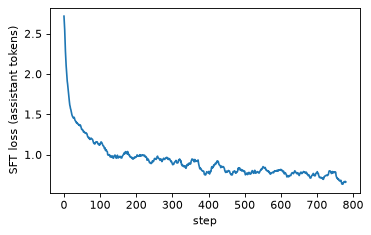

In [6]:
from lm_course.chat import sft_batch
from lm_course.optim import build_optimizer, cosine_schedule
from lm_course.training import lm_loss

PAD = tok.special_id("<|assistant_end|>")  # padding positions are ignored by the loss anyway
STEPS, BATCH = 800, 32


def sft(model: torch.nn.Module, data: list[tuple[list[int], list[int]]], steps: int = STEPS, log_every: int = 200) -> list[float]:
    optimizer = build_optimizer(model, "adamw", lr=1e-3)
    model.train()
    losses = []
    start = time.perf_counter()
    for step in range(steps):
        optimizer.set_lr_multiplier(cosine_schedule(step, steps, 20, min_ratio=0.0))
        batch = [data[(step * BATCH + i) % len(data)] for i in range(BATCH)]
        x, y = sft_batch(batch, PAD)
        loss = lm_loss(model(x), y)
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        losses.append(loss.item())
        if (step + 1) % log_every == 0:
            print(f"step {step + 1}: loss {np.mean(losses[-log_every:]):.3f} ({time.perf_counter() - start:.0f}s)")
    model.eval()
    return losses


set_seed(0)
model = copy.deepcopy(base)
losses = sft(model, rendered)
plt.figure(figsize=(5, 3))
plt.plot(np.convolve(losses, np.ones(20) / 20, mode="valid"))
plt.xlabel("step")
plt.ylabel("SFT loss (assistant tokens)")
plt.show()

## 4. SFT 之後

In [7]:
engine = ChatEngine(model, tok)
for question in ["Tell me a story about a cat.", "What is 47 + 85?", "What is 47 + 85? Think step by step.", "What is 512 + 389? Use the calculator."]:
    reply = engine.reply([{"role": "user", "content": question}], max_tokens=120)
    print(f"USER: {question}")
    print(f"ASSISTANT: {reply.text}")
    if reply.tool_calls:
        print(f"  (tool calls: {reply.tool_calls})")
    print()

USER: Tell me a story about a cat.
ASSISTANT: Once upon a time, there was a little girl named Lily. She had a big, red ball. Lily loved to play with her ball every day. One day, she saw a big, red ball in the park.
Lily wanted to play with the ball, but she was scared. She did not want to go to the park. She wanted to play with the ball, but she was too scared to go away. Lily felt sad.
Lily's mom saw her sad face and came to help. She told Lily to be careful with the ball. Lily listened to her mom and went to play

USER: What is 47 + 85?
ASSISTANT: 47 + 85 = 149.

USER: What is 47 + 85? Think step by step.
ASSISTANT: 7 + 5 = 12, write 2 carry 1. 4 + 8 + 1 = 12, write 2 carry 1. Write the carry 1. So 47 + 85 = 122.

USER: What is 512 + 389? Use the calculator.
ASSISTANT: 512 + 389 = 901.
  (tool calls: [('512+389', '901')])



In [8]:
from lm_course.chat import addition_reward


def accuracy(model: torch.nn.Module, problems: list, style: str) -> float:
    eng = ChatEngine(model, tok)
    return float(np.mean([
        addition_reward(p, eng.reply([{"role": "user", "content": p.question(style)}], max_tokens=90).text)
        for p in problems
    ]))


results = {style: (accuracy(model, test2, style), accuracy(model, test3, style)) for style in ("direct", "steps", "tool")}
print(f"{'answer style':<14}{'2-digit':>10}{'3-digit':>10}   (100 held-out problems each)")
for style, (a2, a3) in results.items():
    print(f"{style:<14}{a2:>10.0%}{a3:>10.0%}")

answer style     2-digit   3-digit   (100 held-out problems each)
direct               14%        0%
steps                89%       76%
tool                100%      100%


**同一個模型、同樣的訓練量**，三種格式的正確率差很多：

- 直接寫答案：模型要在寫出第一位數之前就想好所有進位，5M 參數的小模型大多做不到——它學會了「答案大概多大」，但不準。
- step by step：每一步只需要一位數加法與一個進位，前一步寫在眼前，正確率大幅上升（講義 §2.4）。
- 計算機：模型只要學會「照抄算式」，計算交給程式。

上面的示範剛好兩種都答錯：直接回答寫了 149；step by step 的格式完全正確，但十位數把 4 + 8 + 1 算成 12——錯在單一步的個位數加法，Lab 12 §7 會再遇到這種錯誤。
講故事的回答也值得注意：使用者要一個關於貓的故事，模型寫了一篇通順的故事，卻沒有提到貓。Lab 12 會用強化學習修這件事。

## 5. 遮罩的效果

同樣的資料與步數，但 loss 算在**所有 token** 上（使用者的問題、特殊 token 也算）。

In [9]:
unmasked = [(ids, [1] * len(ids)) for ids, _ in rendered]
set_seed(0)
model_unmasked = copy.deepcopy(base)
_ = sft(model_unmasked, unmasked)
for style in ("direct", "steps", "tool"):
    print(f"{style:<8} 3-digit accuracy: masked {results[style][1]:.0%}, unmasked {accuracy(model_unmasked, test3, style):.0%}")

step 200: loss 1.355 (121s)


step 400: loss 0.884 (241s)


step 600: loss 0.787 (360s)


step 800: loss 0.742 (482s)


direct   3-digit accuracy: masked 0%, unmasked 0%


steps    3-digit accuracy: masked 76%, unmasked 66%


tool     3-digit accuracy: masked 100%, unmasked 99%


只算助理 token 的版本在 step by step 格式高了 10 個百分點（76% vs 66%），另外兩種格式幾乎一樣。但這只是一個種子、100 道題：正確率的標準誤約 ±5 個百分點，兩者相減的誤差約 ±6.5，10 個百分點的差距還不夠下定論。直觀上差距不該太大：使用者的問題很短、很規律，學會生成它們並不佔什麼容量。遮罩的價值在使用者輸入很長或很雜的情況（講義 §2.2）；Shi 等人（2024）也發現，資料少、回答短時，把指令算進 loss 有時反而有幫助。

## 6. 存檔

In [10]:
from lm_course.utils import CHECKPOINT_DIR
from lm_course.model import save_model

save_model(model, CHECKPOINT_DIR / "sft_model.pt", accuracy=results)
print("saved checkpoints/sft_model.pt")

saved checkpoints/sft_model.pt


## 小結

- SFT 用的是和預訓練一樣的 loss，只是資料換成對話、並且只訓練助理的 token。
- 模型學會了格式（何時停、何時呼叫工具），也保留了講故事的能力。
- 回答的**格式**決定了小模型能不能算對：把計算攤開（step by step）或交給工具，比直接寫答案可靠得多。

下一步：[第 12 課](../lessons/12_rl_and_preferences.md)——不給範本，只告訴它對不對。